In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
from sklearn.metrics import ConfusionMatrixDisplay
from utils import audit_utils

In [ ]:
device = audit_utils.setup_env()

internal_path = 'Case2Dataset/test_internal'
external_path = 'Case2Dataset/test_external'

test_internal_loader, test_external_loader, test_internal_dataset, test_external_dataset = audit_utils.get_dataloaders(
    internal_path, external_path, batch_size=16, num_workers=1
)

Using device: cuda:0


In [ ]:
resnet_frozen = audit_utils.setup_model(2, "resnet_frozen_best_case2.pth", device)
print(resnet_frozen)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_sta

In [ ]:
all_predictions, all_labels = audit_utils.evaluate_model(resnet_frozen, test_internal_loader, test_external_loader, device)

for split in ['internal', 'external']:
    predicted_classes = np.argmax(all_predictions[split], axis=1)
    accuracy = (predicted_classes == all_labels[split]).mean()
    print(f"{split} set - Accuracy: {accuracy:.3f}")

Evaluating on external set: 100%|██████████| 19/19 [00:00<00:00, 28.49it/s]

internal set - Accuracy: 0.987
external set - Accuracy: 0.710


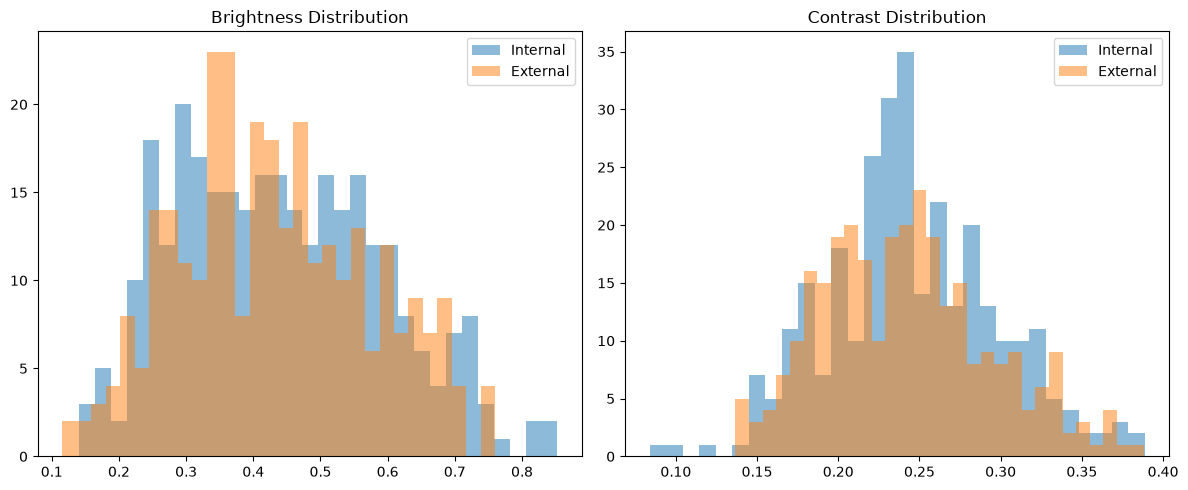

In [ ]:
# Quantitative Dataset Comparison
audit_utils.plot_image_stats(test_internal_dataset, test_external_dataset, save_prefix='plot/case2_')


===== INTERNAL SET =====
Accuracy : 0.987
Precision: 1.000
Recall   : 0.973
F1-score : 0.986


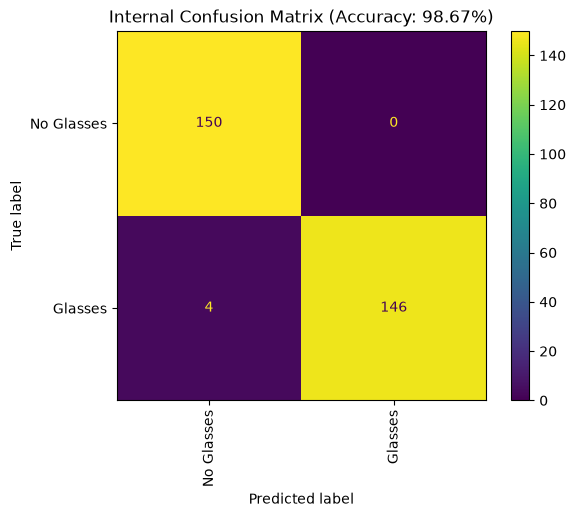

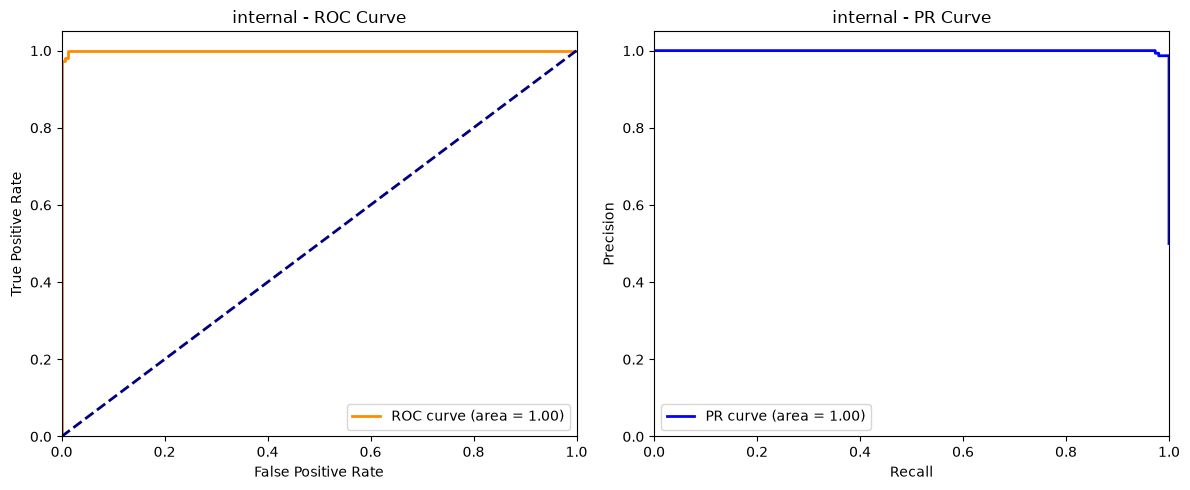


===== EXTERNAL SET =====
Accuracy : 0.710
Precision: 0.756
Recall   : 0.620
F1-score : 0.681


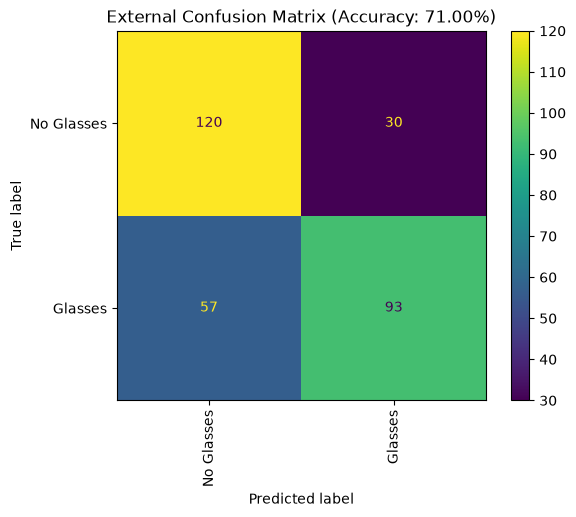

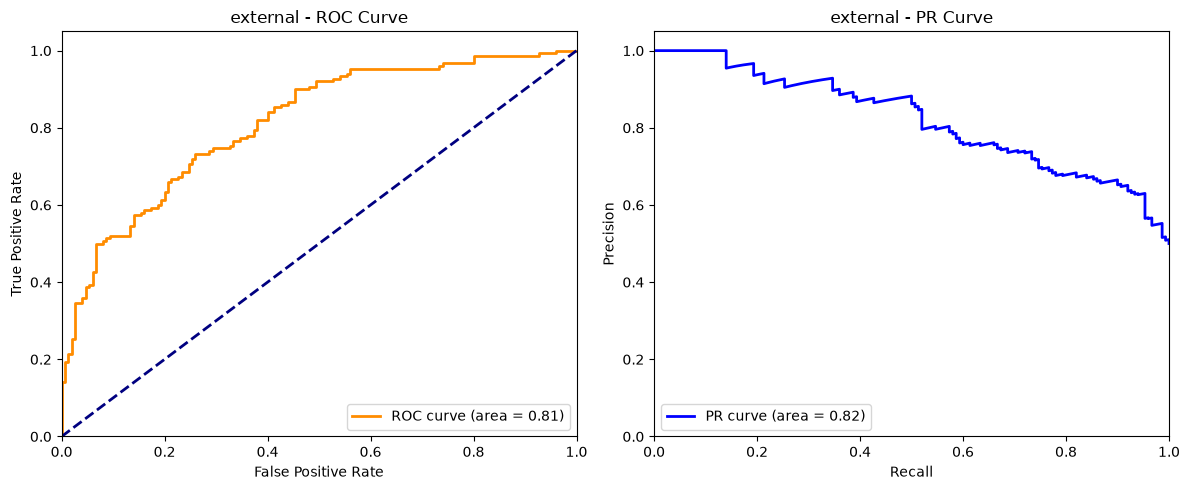

In [ ]:
threshold = 0.5
for split in ['internal', 'external']:
    labels = all_labels[split]
    probs_glasses = all_predictions[split][:, 1]
    preds = probs_glasses >= threshold

    accuracy = (preds == labels.astype(bool)).mean()
    precision, recall, f1 = audit_utils.compute_metrics(labels, probs_glasses, threshold=threshold)

    print(f"\n===== {split.upper()} SET =====")
    print(f"Accuracy : {accuracy:.3f}")
    print(f"Precision: {precision:.3f}")
    print(f"Recall   : {recall:.3f}")
    print(f"F1-score : {f1:.3f}")

    # Plot confusion matrix
    ConfusionMatrixDisplay.from_predictions(
        labels, preds, display_labels=['No Glasses', 'Glasses'], xticks_rotation='vertical'
    )
    plt.title(f'{split.capitalize()} Confusion Matrix (Accuracy: {accuracy * 100:.2f}%)')
    plt.savefig(f'plot/case2_cm_{split}.png')
    plt.show()
    
    # Plot ROC and PR curves
    audit_utils.plot_roc_pr_curves(labels, probs_glasses, split, save_prefix='plot/case2_')

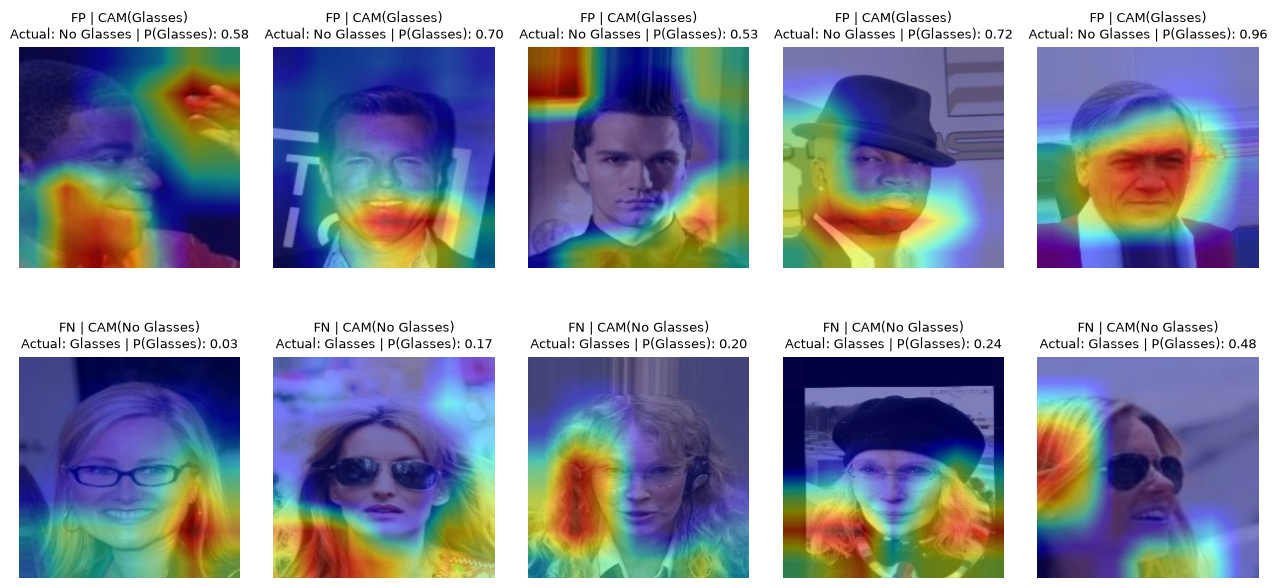

In [ ]:
# Get external labels and predicted probabilities
labels = all_labels['external']
probs_glasses = all_predictions['external'][:,1]
preds = probs_glasses >= 0.5

fp_indices = np.where((labels == 0) & (preds == 1))[0]
fn_indices = np.where((labels == 1) & (preds == 0))[0]

np.random.seed(10)
selected_fp = np.random.choice(fp_indices, 5, replace=False)
selected_fn = np.random.choice(fn_indices, 5, replace=False)

# CAM Implementation
activation = {}

def get_activation(name):
    def hook(model, input, output):
        activation[name] = output.detach()
    return hook

target_layer = resnet_frozen.layer4[1].conv2
hook_handle = target_layer.register_forward_hook(get_activation('layer4_conv2'))

cam_groups = [
    ('FP', selected_fp),
    ('FN', selected_fn)
]

resnet_frozen.eval()
fig, axes = plt.subplots(2, 5, figsize=(16, 7))

with torch.no_grad():
    for row, (result, indices) in enumerate(cam_groups):
        for col, idx in enumerate(indices):
            x, y = test_external_dataset[idx]
            x = x.to(device).unsqueeze(0)

            # Run inference
            output = resnet_frozen(x)
            pred = torch.argmax(output, dim=1).item()
            prob_glasses = torch.softmax(output, dim=1)[0, 1].item()

            # CAM computation using audit_utils
            conv_feature_map = activation['layer4_conv2'][0]
            fc_weights = resnet_frozen.fc.weight[pred].detach()
            cam = audit_utils.compute_cam(conv_feature_map, fc_weights, image_size=(x.shape[2], x.shape[3]))

            x_display = audit_utils.denormalize_image(x.squeeze(0).cpu())
            actual = 'Glasses' if y == 1 else 'No Glasses'
            predicted = 'Glasses' if pred == 1 else 'No Glasses'

            axes[row, col].imshow(x_display)
            axes[row, col].imshow(cam, alpha=0.5, cmap='jet')
            axes[row, col].set_title(
                f'{result} | CAM({predicted})\n'
                f'Actual: {actual} | P(Glasses): {prob_glasses:.2f}',
                fontsize=9
            )
            axes[row, col].axis('off')

axes[0,0].set_ylabel('FP\nNo Glasses -> Glasses', fontsize=11, labelpad=10)
axes[1,0].set_ylabel('FN\nGlasses -> No Glasses', fontsize=11, labelpad=10)

plt.subplots_adjust(hspace=0.35, wspace=0.15)
plt.savefig('plot/case2_cam.png')
plt.show()

hook_handle.remove()

## Evaluation Processing Reasoning
We evaluate the classification metrics and ROC/PR curves to confirm the performance disparity between the internal and external test sets. Since the external dataset also consists of well-lit images (ruling out lighting/camera quality drops), we must investigate what specific subgroups are failing. We use CAM on False Positives and False Negatives to determine if the model is ignoring the eye region and instead relying on other demographic or facial features.

## Diagnosis
The root cause is a **spurious correlation tied to demographic or facial biases** (e.g., makeup, gender, or hairstyle). Because the model works in well-lit conditions for some users but fails for others, it indicates that the training data contained imbalanced correlations (e.g., predominantly male subjects wearing glasses, or subjects without makeup wearing glasses). The model learned these proxy features instead of genuinely detecting the frames of the glasses.

## Evidence
1. **Performance Disparity**: Metrics show a drop in accuracy on the external set despite similar image quality (as confirmed by the dataset statistics).
2. **CAM Saliency Maps**: The CAM visualisations for the failure cases (FPs and FNs) show the model is heavily weighting regions outside the eyes—such as the hair, the cheekbones, or the jawline. For instance, in False Negatives, it may ignore the glasses entirely if the subject possesses demographic features the model associates with the 'No Glasses' class.

## Recommendations
1. **Dataset De-biasing**: Audit the training dataset for demographic imbalances. Ensure an equal representation of subgroups (e.g., gender, race, makeup usage) across both the 'Glasses' and 'No Glasses' classes to break the spurious correlation.
2. **Feature Disentanglement / Adversarial Training**: Employ adversarial training techniques to penalize the model for learning protected attributes (like gender or race), forcing it to rely only on the glasses.
3. **Spatial Priors**: Similar to Case 1, use a landmark detector to crop heavily around the eye region, preventing the model from utilizing hair or jawline features.